<a href="https://colab.research.google.com/github/VivekAChawla/camm_hackathon/blob/k4my4r/Metallographic_Images_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


[download_folder] id=1vzoPhQbyKcs_piTncvK9Q3hEi2UaaAeM -> images


Retrieving folder contents


Retrieving folder 1hK2GSYsnhYZIzb-jKftTdJHXDXmtH0Ue Laser
Processing file 1xI6YINjxoWPdVn3w5wquZRGFb8BfjAEt img1001.png
Processing file 1s5ekGlZ4L0bufYjbDrFXQMUlmt0UzLJN img1002.png
Processing file 1IapNUbT9THw1lp7ogSWJw8-4ZZAapWut img1003.jpg
Processing file 1aSWsr3pFCM5_TVfLQGandECCcTWmqCIm img1004.jpg
Processing file 1ah0cyjL16Dq5SUk523gjk0_gxtfuwh6S img1005.jpg
Processing file 1RvGNATrhcbd-JuHQSCZfGb_6mUPjaFoe img1006.png
Processing file 1x4jS8V6obo3W4D2p_YvGf0qulBR4wirm img1007.jpg
Processing file 1LutoApuWzTZuB6K7NH8sZLqz5bsQGzqD img1008.jpg
Processing file 1QR96kNuqSKcQZEJQY6Dj90YD6x0msr3l img1009.jpg
Processing file 1wXLx7HRPotvOgaq5wT5T7L5u0-1RV90B img1010.jpg
Retrieving folder 1P9453P3fdHx9cz6jRV5ojWnu4EUAvq9r Optical
Processing file 1G8QDEkE17C2e4CMt_kq7CV1UDoZYC3yQ img001.jpg
Processing file 1eEoMxurpdgL3dzccXLYKnMQ5yGoDBKyO img002.jpg
Processing file 1C5zvXEOEF_tsPbAxteSg6LnptqTbIE8r img003.jpg
Processing file 1Vwsmu9hMulUDhKrLbqbOux3ya7lrj5eR img004.jpg
Processing file 17

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1xI6YINjxoWPdVn3w5wquZRGFb8BfjAEt
To: /content/images/Laser/img1001.png
100%|██████████| 1.08M/1.08M [00:00<00:00, 21.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1s5ekGlZ4L0bufYjbDrFXQMUlmt0UzLJN
To: /content/images/Laser/img1002.png
100%|██████████| 547k/547k [00:00<00:00, 8.77MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IapNUbT9THw1lp7ogSWJw8-4ZZAapWut
To: /content/images/Laser/img1003.jpg
100%|██████████| 348k/348k [00:00<00:00, 10.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aSWsr3pFCM5_TVfLQGandECCcTWmqCIm
To: /content/images/Laser/img1004.jpg
100%|██████████| 271k/271k [00:00<00:00, 9.08MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ah0cyjL16Dq5SUk523gjk0_gxtfuwh6S
To: /content/images/Laser/img1005.jpg
100%|██████████| 219k/219k [00:00<00:00, 5.49MB/s]
Downloading...
Fro


Found 41 images under images


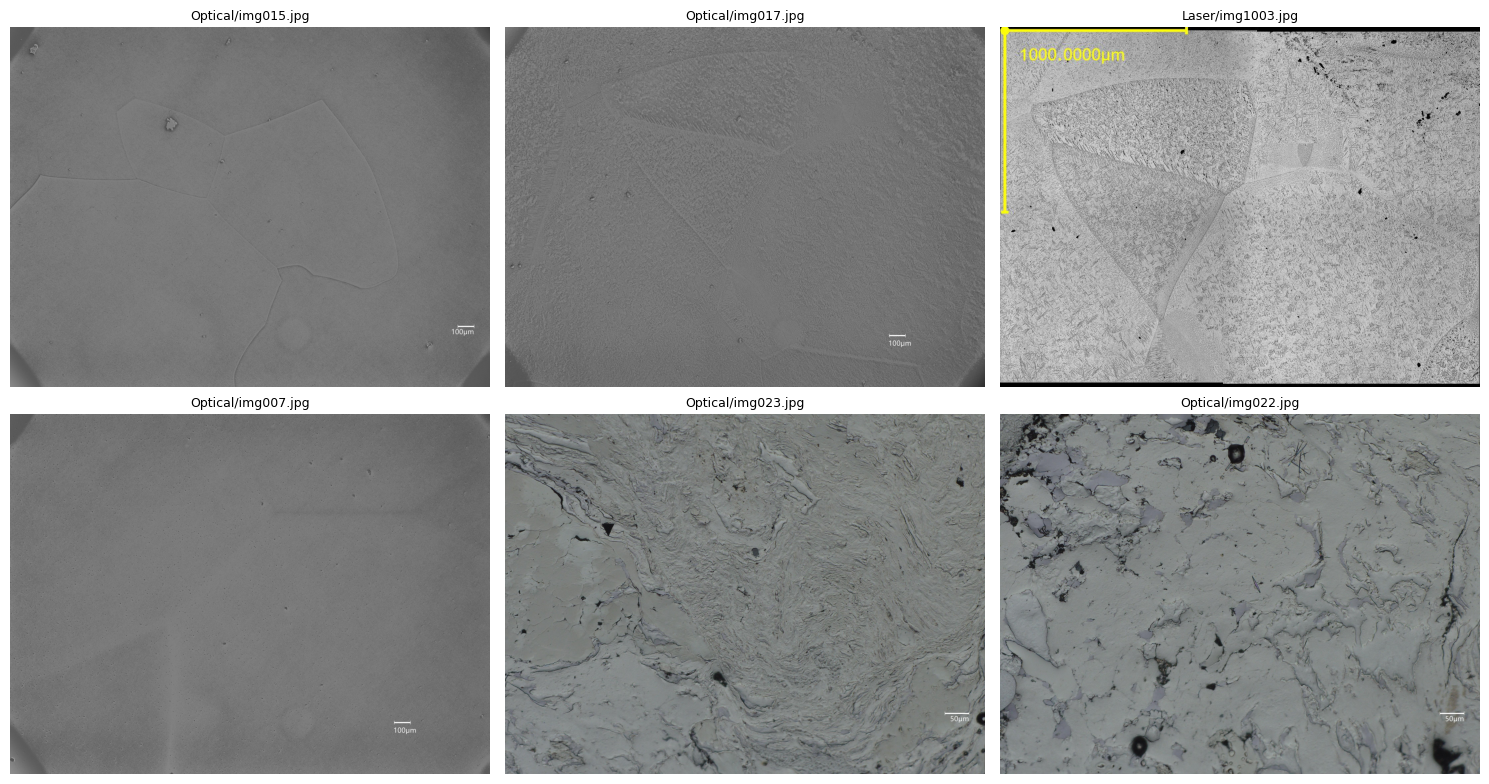

In [3]:
!pip -q install gdown==5.2.0 imageio
import os, glob, random, matplotlib.pyplot as plt
import gdown, imageio.v2 as iio

# ===== EDIT: top-level shared folder ID only =====
TOP_ID = "1vzoPhQbyKcs_piTncvK9Q3hEi2UaaAeM"  # from .../drive/folders/<ID>
OUT_DIR = "images"

os.makedirs(OUT_DIR, exist_ok=True)

# 1) Download the folder (tolerant to partial failures)
print(f"\n[download_folder] id={TOP_ID} -> {OUT_DIR}")
gdown.download_folder(
    id=TOP_ID, output=OUT_DIR,
    quiet=False, use_cookies=False,
    remaining_ok=True
)

# 2) Find images anywhere under images/ (recursive)
EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
files = sorted([p for ext in EXTS for p in glob.glob(os.path.join(OUT_DIR, "**", f"*{ext}"), recursive=True)])
print(f"\nFound {len(files)} images under {OUT_DIR}")

# 3) Preview K random images from the whole set
def show_samples(paths, title="Sample images", k=6, seed=0):
    if not paths:
        print("[INFO] No images to show.")
        return
    random.seed(seed)
    picks = random.sample(paths, min(k, len(paths)))
    cols = min(3, len(picks))
    rows = (len(picks) + cols - 1) // cols
    plt.figure(figsize=(5*cols, 4*rows))
    for i, p in enumerate(picks, 1):
        try:
            img = iio.imread(p)
        except Exception as e:
            print(f"[WARN] Could not read {p}: {e}")
            continue
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(os.path.relpath(p, OUT_DIR), fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(files, k=6)
